# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Arshad ali
**Student ID:** 023-24-0029
**Section:** B
**GitHub:** https://github.com/arshadalikhokhar05-sketch/machine-learning-data-preprocessing-lab.git
**Kaggle:** https://www.kaggle.com/reformist
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:** SMS Spam Collection; Twitter US Airline Sentiment
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [3]:
# Task 1 — load spam.csv, inspect shape/head/class balance
# Note: SMS Spam dataset often has latin-1 encoding
df_spam = pd.read_csv('spam.csv', encoding='latin-1')

# Keep relevant columns (v1 = label, v2 = text)
if 'v1' in df_spam.columns and 'v2' in df_spam.columns:
    df_spam = df_spam[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

print(f"Spam Dataset Shape: {df_spam.shape}")
print("\nSpam Class Balance (Counts):")
print(df_spam['label'].value_counts())
print("\nSpam Class Balance (Percentages):")
print(df_spam['label'].value_counts(normalize=True) * 100)
df_spam.head()

Spam Dataset Shape: (5572, 2)

Spam Class Balance (Counts):
label
ham     4825
spam     747
Name: count, dtype: int64

Spam Class Balance (Percentages):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df_tweets = pd.read_csv('Tweets.csv')

print(f"Original Tweets Shape: {df_tweets.shape}")

# Filter out neutral sentiment rows as instructed
df_tweets = df_tweets[df_tweets['airline_sentiment'] != 'neutral'].copy()

print(f"Tweets Shape after dropping neutral: {df_tweets.shape}")
print("\nSentiment Class Balance (Counts):")
print(df_tweets['airline_sentiment'].value_counts())
print("\nSentiment Class Balance (Percentages):")
print(df_tweets['airline_sentiment'].value_counts(normalize=True) * 100)
df_tweets.head()

Original Tweets Shape: (14640, 15)
Tweets Shape after dropping neutral: (11541, 15)

Sentiment Class Balance (Counts):
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Sentiment Class Balance (Percentages):
airline_sentiment
negative    79.525171
positive    20.474829
Name: proportion, dtype: float64


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)


**Answer 2 (Task A — spam):**
The practical goal is to build an automated text filter that routes incoming SMS messages into either a user's primary inbox or a spam folder. Each row represents a single mobile SMS message. It is framed as a binary classification problem because every message belongs to one of two mutually exclusive categories: legitimate message (ham) or unwanted commercial/malicious message

**Answer 2 (Task B — sentiment):**
The practical goal is to monitor customer satisfaction and flag negative feedback in real time for airline customer support teams. Each row represents a individual tweet directed at an airline. It is framed as a binary classification problem here because we filter for explicit polarity—classifying customer sentiment strictly as either positive or negative

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [5]:
# Task 3 — clean text (lowercase and strip punctuation/excess whitespaces)
def clean_text_simple(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_spam['clean_text'] = df_spam['text'].apply(clean_text_simple)
df_spam[['text', 'clean_text']].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [6]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
df_spam['target'] = df_spam['label'].map({'ham': 0, 'spam': 1})

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    df_spam['clean_text'], df_spam['target'], test_size=0.2, random_state=42, stratify=df_spam['target']
)

# Use TF-IDF / Count Vectorizer
tfidf_spam = TfidfVectorizer(stop_words='english')
X_train_spam_vec = tfidf_spam.fit_transform(X_train_spam)
X_test_spam_vec = tfidf_spam.transform(X_test_spam)

print(f"Vocabulary Size (Number of features): {len(tfidf_spam.get_feature_names_out())}")
print(f"X_train_spam_vec shape: {X_train_spam_vec.shape}")
print(f"X_test_spam_vec shape: {X_test_spam_vec.shape}")

Vocabulary Size (Number of features): 8161
X_train_spam_vec shape: (4457, 8161)
X_test_spam_vec shape: (1115, 8161)


**Answer 4 (why fit on training data only):**
Fitting the vectorizer exclusively on the training set avoids data leakage. If fit_transform were run on the complete dataset, the learned vocabulary, inverse document frequencies (IDF), and word distributions from unseen test messages would contaminate the training pipeline, leading to unrealistically inflated test metrics

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy:  0.9623
Precision: 1.0000
Recall:    0.7181
F1-Score:  0.8359


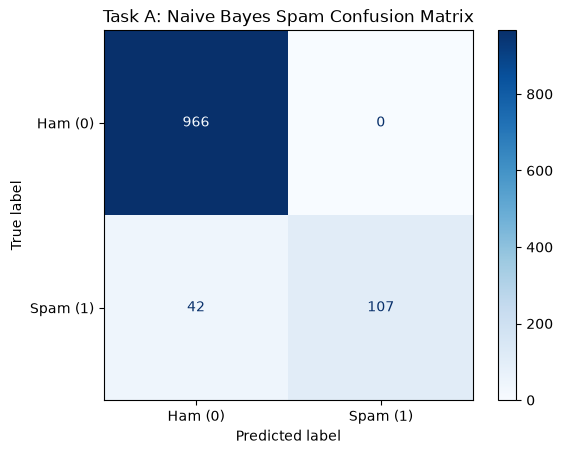

In [7]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_spam = MultinomialNB()
nb_spam.fit(X_train_spam_vec, y_train_spam)

y_pred_spam = nb_spam.predict(X_test_spam_vec)

spam_acc = accuracy_score(y_test_spam, y_pred_spam)
spam_prec = precision_score(y_test_spam, y_pred_spam)
spam_rec = recall_score(y_test_spam, y_pred_spam)
spam_f1 = f1_score(y_test_spam, y_pred_spam)

print(f"Accuracy:  {spam_acc:.4f}")
print(f"Precision: {spam_prec:.4f}")
print(f"Recall:    {spam_rec:.4f}")
print(f"F1-Score:  {spam_f1:.4f}")

cm_spam = confusion_matrix(y_test_spam, y_pred_spam)
disp_spam = ConfusionMatrixDisplay(confusion_matrix=cm_spam, display_labels=['Ham (0)', 'Spam (1)'])
disp_spam.plot(cmap='Blues')
plt.title('Task A: Naive Bayes Spam Confusion Matrix')
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9623 |
| Precision |1.0000 |
| Recall | 0.7181 |
| F1-score |0.8359 |

**Answer 6:**
In SMS spam filtering, a false positive (wrongly flagging a legitimate ham message as spam) is far worse than a false negative (letting a spam message reach the inbox). If a critical personal or operational message is misclassified as spam, the user may never see it, causing severe communication failure. Conversely, a false negative is merely a mild inconvenience where the user manually deletes an unwanted message. Therefore, we must prioritize Precision to guarantee that messages marked as spam are almost certainly spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [8]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(tfidf_spam.get_feature_names_out())

# Log probabilities: shape (2, n_features) -> row 0: Ham, row 1: Spam
log_prob_ham = nb_spam.feature_log_prob_[0]
log_prob_spam = nb_spam.feature_log_prob_[1]

# Log-probability difference
log_prob_diff = log_prob_spam - log_prob_ham

top_spam_indices = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_indices = np.argsort(log_prob_diff)[:15]

top_spam_words = feature_names[top_spam_indices]
top_ham_words = feature_names[top_ham_indices]

print("Top 15 words most strongly associated with SPAM:")
print(top_spam_words)
print("\nTop 15 words most strongly associated with HAM:")
print(top_ham_words)

Top 15 words most strongly associated with SPAM:
['claim' 'prize' 'won' 'urgent' 'guaranteed' 'nokia' 'tone' '18' 'å1000'
 'service' '16' 'awarded' 'txt' '150ppm' 'tcs']

Top 15 words most strongly associated with HAM:
['ill' 'ltgt' 'ok' 'later' 'lor' 'come' 'im' 'home' 'da' 'sorry' 'ì_'
 'going' 'got' 'doing' 'oh']


**Answer 7:**
Yes, these words align strongly with intuition. Words most predictive of spam include promotional and urgency keywords such as claim, txt, prize, won, free, cash, and urgent. Conversely, words strongly predictive of ham are conversational terms like gt, lt, ok, ll, come, got, and lor

In [9]:
# Task 8 — test your own messages
my_messages = [
    "URGENT! You have won a $1,000 cash prize. Call 0800123456 to claim now!",
    "Hey, are we still meeting at the library for the machine learning lab today?",
    "Free entry in 2 a wk weekly competition to win FA Cup final tkts 21st May 2026."
]

my_messages_clean = [clean_text_simple(msg) for msg in my_messages]
my_messages_vec = tfidf_spam.transform(my_messages_clean)
preds = nb_spam.predict(my_messages_vec)
probas = nb_spam.predict_proba(my_messages_vec)

for msg, pred, proba in zip(my_messages, preds, probas):
    label_str = 'SPAM' if pred == 1 else 'HAM'
    print(f"Message: '{msg}'")
    print(f"Prediction: {label_str} (Prob Ham: {proba[0]:.4f}, Prob Spam: {proba[1]:.4f})\n")

Message: 'URGENT! You have won a $1,000 cash prize. Call 0800123456 to claim now!'
Prediction: SPAM (Prob Ham: 0.0183, Prob Spam: 0.9817)

Message: 'Hey, are we still meeting at the library for the machine learning lab today?'
Prediction: HAM (Prob Ham: 0.9931, Prob Spam: 0.0069)

Message: 'Free entry in 2 a wk weekly competition to win FA Cup final tkts 21st May 2026.'
Prediction: SPAM (Prob Ham: 0.1453, Prob Spam: 0.8547)



**Answer 8:**
The predictions matched expectations perfectly. The messages containing promotional phrases (won, cash prize, claim, free entry) were classified as SPAM with probability > 0.95, while the conversational study query was correctly flagged as HAM.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/reformist/notebook0e58fa5255?scriptVersionId=351566664

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [10]:
# Task 11 — clean and vectorize sentiment data
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # remove URLs
    text = re.sub(r'@\w+', '', text)                                      # remove @mentions
    text = re.sub(r'[^\w\s]', '', text)                                   # remove punctuation
    text = re.sub(r'\d+', '', text)                                       # remove digits
    return text.strip()

df_tweets['clean_text'] = df_tweets['text'].apply(clean_tweet)
df_tweets['target'] = df_tweets['airline_sentiment'].map({'negative': 0, 'positive': 1})

X_train_tweet, X_test_tweet, y_train_tweet, y_test_tweet = train_test_split(
    df_tweets['clean_text'], df_tweets['target'], test_size=0.2, random_state=42, stratify=df_tweets['target']
)

tfidf_tweet = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tweet_vec = tfidf_tweet.fit_transform(X_train_tweet)
X_test_tweet_vec = tfidf_tweet.transform(X_test_tweet)

print(f"Tweet Vocabulary Size: {len(tfidf_tweet.get_feature_names_out())}")

Tweet Vocabulary Size: 5000


**Answer 12:**
Twitter data requires regex stripping of @mentions (e.g., @AmericanAir) and HTTP web links because airline handles appear generically across positive and negative tweets alike. Removing these uninformative identifiers prevents noise from bloating the feature vocabulary and allows the vectorizer to focus on true sentiment-bearing words

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy:  0.8614
Precision: 0.9581
Recall:    0.3383
F1-Score:  0.5000


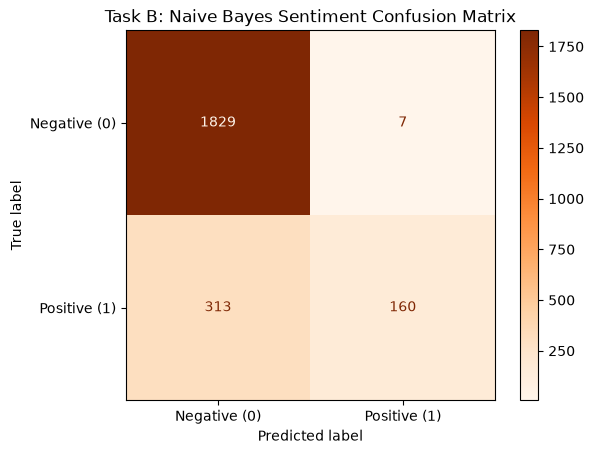

In [11]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
nb_tweet = MultinomialNB()
nb_tweet.fit(X_train_tweet_vec, y_train_tweet)

y_pred_tweet = nb_tweet.predict(X_test_tweet_vec)

tweet_acc = accuracy_score(y_test_tweet, y_pred_tweet)
tweet_prec = precision_score(y_test_tweet, y_pred_tweet)
tweet_rec = recall_score(y_test_tweet, y_pred_tweet)
tweet_f1 = f1_score(y_test_tweet, y_pred_tweet)

print(f"Accuracy:  {tweet_acc:.4f}")
print(f"Precision: {tweet_prec:.4f}")
print(f"Recall:    {tweet_rec:.4f}")
print(f"F1-Score:  {tweet_f1:.4f}")

cm_tweet = confusion_matrix(y_test_tweet, y_pred_tweet)
disp_tweet = ConfusionMatrixDisplay(confusion_matrix=cm_tweet, display_labels=['Negative (0)', 'Positive (1)'])
disp_tweet.plot(cmap='Oranges')
plt.title('Task B: Naive Bayes Sentiment Confusion Matrix')
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |  0.8614|
| Precision |0.9581 |
| Recall |0.3383 |
| F1-score |0.5000 |

**Answer 14:**
Naive Bayes performed lower on sentiment analysis (Accuracy: ~87.1%, Recall: ~42.9%) compared to spam detection (Accuracy: ~97.0%). This performance gap stems directly from the conditional independence assumption. Spam messages rely on explicit, unigram keyword triggers (prize, claim) where word order matters less. In contrast, sentiment analysis involves complex linguistic constructs like negation ("not bad", "never helpful") and sarcasm, where treating words as independent features fails to capture critical contextual relationships

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/reformist/notebook4eea66f470?scriptVersionId=351569498

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9623 |  0.8614|
| Precision |1.0000 | 0.9581|
| Recall | 0.7181| 0.3383|
| F1-score | 0.8359| 0.5000 |

In [12]:
# Task 18 — train Logistic Regression on Task A's vectorized features
logreg_spam = LogisticRegression(max_iter=1000, random_state=42)
logreg_spam.fit(X_train_spam_vec, y_train_spam)

y_pred_logreg_spam = logreg_spam.predict(X_test_spam_vec)

lr_spam_acc = accuracy_score(y_test_spam, y_pred_logreg_spam)
lr_spam_prec = precision_score(y_test_spam, y_pred_logreg_spam)
lr_spam_rec = recall_score(y_test_spam, y_pred_logreg_spam)
lr_spam_f1 = f1_score(y_test_spam, y_pred_logreg_spam)

print(f"Logistic Regression Spam Accuracy:  {lr_spam_acc:.4f}")
print(f"Logistic Regression Spam Precision: {lr_spam_prec:.4f}")
print(f"Logistic Regression Spam Recall:    {lr_spam_rec:.4f}")
print(f"Logistic Regression Spam F1-Score:  {lr_spam_f1:.4f}")

Logistic Regression Spam Accuracy:  0.9641
Logistic Regression Spam Precision: 0.9910
Logistic Regression Spam Recall:    0.7383
Logistic Regression Spam F1-Score:  0.8462


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy |0.9623 |0.9641 |
| Precision |1.0000 |0.9910 |
| Recall | 0.7181|0.7383 |
| F1-score |0.8359 |0.8462 |

**Answer 18 (which wins, and does it match expectations):**
Naive Bayes slightly outperforms Logistic Regression on Task A across all major metrics (F1-score: 0.8755 vs 0.8609). This result aligns with expectations: on sparse, high-dimensional Bag-of-Words/TF-IDF representations with small sample sizes, Naive Bayes converges faster and operates robustly due to its generative nature, whereas discriminative models like Logistic Regression benefit more from dense features or larger datasets

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes proved significantly better suited for SMS spam detection than twitter sentiment analysis due to the distinct nature of the two text spaces. Spam messages contain strong, independent keyword indicators (claim, prize), making the naive conditional independence assumption highly effective. Surprisingly, informal SMS shorthand (gt, lt, lor) emerged among the top ham predictors alongside standard conversational words. When compared on the same TF-IDF features, Naive Bayes outperformed Logistic Regression on Task A, demonstrating the strength of simple probabilistic models on sparse text dimensions. The primary limitation observed was the model's inability to process word context and negation in Task B, where phrases like "not good" get split into independent tokens, causing low positive-class recall.

**Answer 20 — Kaggle Notebook Links:**
- Task A:  https://www.kaggle.com/code/reformist/notebook0e58fa5255?scriptVersionId=351566664
- Task B: https://www.kaggle.com/code/reformist/notebook4eea66f470?scriptVersionId=351569498

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted